# Bayesian updating of Portugal's 2025 GDP after the revised population estimate

This notebook implements a probabilistic alternative to a denominator-only correction of GDP per capita.

The key idea is simple: a higher resident-population estimate lowers GDP per capita if GDP is fixed, but GDP itself is also an estimate. A serious analysis should update both population and GDP with uncertainty.

The workflow is:

1. Load the longest historical population and macroeconomic series available.
2. Patch the revised 2025 INE population estimate.
3. Estimate the posterior distribution of 2025 population.
4. Estimate the posterior distribution of 2025 GDP using historical dynamics and the observed 2025 real GDP growth signal.
5. Compute posterior GDP per capita.
6. Run a transparent sensitivity analysis for the GDP-per-capita-in-PPS index.


## 1. Imports and project path

The model avoids heavy probabilistic programming frameworks. It uses a conjugate Bayesian linear regression and normal-normal updating. That keeps the assumptions visible and easy to audit.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from pt_gdp_bayes.bayes import summarize_samples
from pt_gdp_bayes.data_sources import (
    DataDownloadError,
    fetch_world_bank_panel,
    get_known_value,
    load_known_observations,
    patch_manual_observation,
)
from pt_gdp_bayes.model import (
    estimate_gdp_posterior_samples,
    estimate_population_posterior_samples,
    estimate_pps_index_samples,
)
from pt_gdp_bayes.plotting import plot_posterior_histogram

pd.set_option("display.max_columns", 100)


C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## 2. Manual official anchors

Some high-value values are included as manual observations because international APIs may lag national statistical revisions.

The most important observation is the revised 2025 resident population estimate. This is treated as a noisy observation of latent true population, not as a deterministic truth.


In [2]:
known_observations = load_known_observations(PROJECT_ROOT / "data" / "known_observations.csv")
known_observations


,variable,country,year,value,unit,source,notes
0,resident_population,Portugal,2025,1.142403e+07,persons,INE Press Release 771843617,Resident population on 31 December 2025; revis...
1,foreign_residents,Portugal,2025,1.597539e+06,persons,INE Press Release 771843617,Foreign resident population in 2025.
2,foreign_resident_share,Portugal,2025,1.400000e-01,share,INE Press Release 771843617,Foreign residents as share of total resident p...
3,real_gdp_growth,Portugal,2025,1.900000e-02,log_approx_or_decimal,INE Press Release 706214887,GDP volume growth in 2025.
4,preliminary_gdp_pc_pps_index,Portugal,2025,8.130000e+01,EU27_2025_100,User supplied article citing European Commissi...,Used only for the PPS-index sensitivity block.
5,population_correction_factor,Portugal,2025,1.056000e+00,ratio,User supplied article calculations,Ratio between revised population estimate and ...
6,article_corrected_gdp_pc_pps_index,Portugal,2025,7.700000e+01,EU27_2025_100,User supplied article calculations,Reference result from the mechanical denominat...


## 3. Long historical series

The first source used here is the World Bank API because it usually gives a long annual window from 1960 onward.

For a production-grade analysis, I would also add AMECO and Eurostat as parallel sources and estimate source-specific measurement errors. The code is structured so that layer can be added without rewriting the Bayesian model.


In [3]:
WORLD_BANK_INDICATORS = {
    "population": "SP.POP.TOTL",
    "gdp_current_usd": "NY.GDP.MKTP.CD",
    "gdp_constant_2015_usd": "NY.GDP.MKTP.KD",
    "real_gdp_growth_pct": "NY.GDP.MKTP.KD.ZG",
    "gdp_deflator_pct": "NY.GDP.DEFL.KD.ZG",
    "unemployment_pct": "SL.UEM.TOTL.ZS",
    "labor_force": "SL.TLF.TOTL.IN",
    "exports_current_usd": "NE.EXP.GNFS.CD",
    "imports_current_usd": "NE.IMP.GNFS.CD",
    "household_consumption_current_usd": "NE.CON.PRVT.CD",
    "gross_capital_formation_current_usd": "NE.GDI.TOTL.CD",
}

try:
    panel = fetch_world_bank_panel(
        "PRT",
        WORLD_BANK_INDICATORS,
        start_year=1960,
        end_year=2025,
    )
except DataDownloadError as exc:
    raise RuntimeError(
        "Could not download the World Bank data. Run this notebook on a machine with internet access. "
        "The model implementation is complete, but the runtime must be able to reach external APIs."
    ) from exc

panel.tail()


,year,population,gdp_current_usd,gdp_constant_2015_usd,real_gdp_growth_pct,gdp_deflator_pct,unemployment_pct,labor_force,exports_current_usd,imports_current_usd,household_consumption_current_usd,gross_capital_formation_current_usd
61,2021,10361831.0,2.560559e+11,2.149842e+11,5.558757,2.019777,6.712,5114630.0,1.063872e+11,1.134971e+11,1.622676e+11,5.360470e+10
62,2022,10434332.0,2.568987e+11,2.300026e+11,6.985841,5.327500,6.138,5245513.0,1.271178e+11,1.332854e+11,1.638168e+11,5.490828e+10
63,2023,10578174.0,2.923238e+11,2.371326e+11,3.099979,7.487648,6.498,5395411.0,1.378467e+11,1.344116e+11,1.796602e+11,5.991842e+10
64,2024,10694681.0,3.132712e+11,2.422065e+11,2.139672,4.813077,6.500,5450166.0,1.433896e+11,1.376034e+11,NaN,6.380439e+10
65,2025,NaN,NaN,NaN,NaN,NaN,6.164,5419014.0,NaN,NaN,NaN,NaN


## 4. Patch the revised 2025 INE population estimate

This is the central observation in the debate.

If the population used in earlier GDP-per-capita calculations was too low, then the earlier GDP-per-capita value was probably too high. The Bayesian model does not stop there. It also lets GDP move through a separate posterior distribution.


In [4]:
revised_population_2025 = get_known_value(known_observations, "resident_population", 2025)
real_gdp_growth_2025 = get_known_value(known_observations, "real_gdp_growth", 2025)
preliminary_pps_index = get_known_value(known_observations, "preliminary_gdp_pc_pps_index", 2025)
population_correction_factor = get_known_value(known_observations, "population_correction_factor", 2025)

panel = patch_manual_observation(
    panel,
    year=2025,
    column="population",
    value=revised_population_2025,
    note="Patched with revised INE 2025 resident population estimate",
)

panel.loc[panel["year"].between(2020, 2025), ["year", "population", "gdp_current_usd", "gdp_deflator_pct", "manual_patch_notes"]]


,year,population,gdp_current_usd,gdp_deflator_pct,manual_patch_notes
60,2020,10297081.0,2.296188e+11,2.103143,
61,2021,10361831.0,2.560559e+11,2.019777,
62,2022,10434332.0,2.568987e+11,5.327500,
63,2023,10578174.0,2.923238e+11,7.487648,
64,2024,10694681.0,3.132712e+11,4.813077,
65,2025,11424031.0,NaN,NaN,Patched with revised INE 2025 resident populat...


## 5. Posterior population estimate

The prior comes from historical log population growth. The 2025 INE estimate is then added as a noisy observation.

This gives us a posterior distribution rather than a single deterministic population value.


In [5]:
population_result = estimate_population_posterior_samples(
    panel,
    target_year=2025,
    population_col="population",
    observed_population=revised_population_2025,
    observation_relative_sd=0.001,
    n_samples=20_000,
    random_seed=7,
)

population_summary = summarize_samples(population_result.samples)
population_summary


{'mean': 11412238.726253329,
 'median': 11412230.22462444,
 'sd': 11250.840331720294,
 'q5': 11393788.109131427,
 'q95': 11430692.7368941}

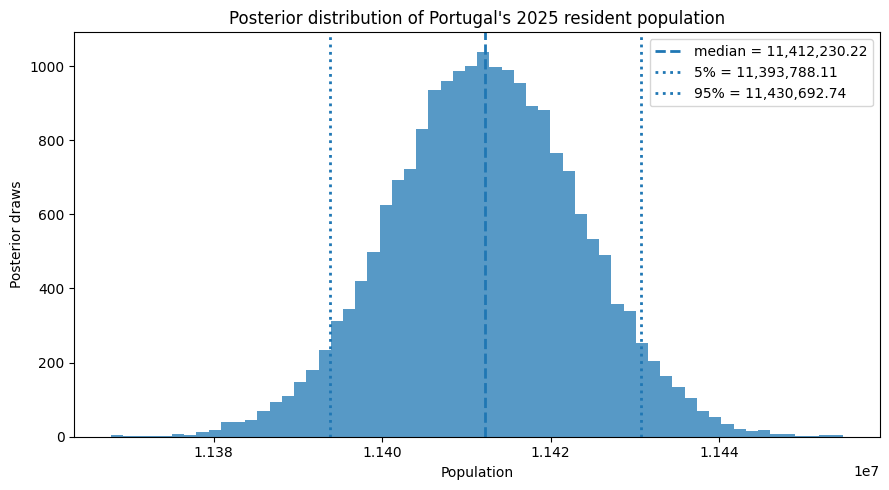

In [6]:
plot_posterior_histogram(
    population_result.samples,
    title="Posterior distribution of Portugal's 2025 resident population",
    xlabel="Population",
)


## 6. Posterior GDP estimate

This step is where the model improves on a denominator-only correction.

The model combines:

- historical nominal GDP growth dynamics;
- population growth;
- GDP-deflator growth;
- the observed 2025 real GDP growth signal.

This means that the 2025 GDP estimate is not assumed fixed. It is updated with uncertainty.


In [7]:
gdp_result = estimate_gdp_posterior_samples(
    panel,
    target_year=2025,
    population_samples=population_result.samples,
    gdp_col="gdp_current_usd",
    population_col="population",
    deflator_col="gdp_deflator_pct",
    known_real_gdp_growth=real_gdp_growth_2025,
    real_growth_observation_sd=0.003,
    n_samples=20_000,
    random_seed=11,
)

gdp_summary = summarize_samples(gdp_result.gdp_samples)
gdp_summary


{'mean': 339829042119.66895,
 'median': 339450484410.4099,
 'sd': 17013184957.4075,
 'q5': 312269153159.0523,
 'q95': 368717404955.9662}

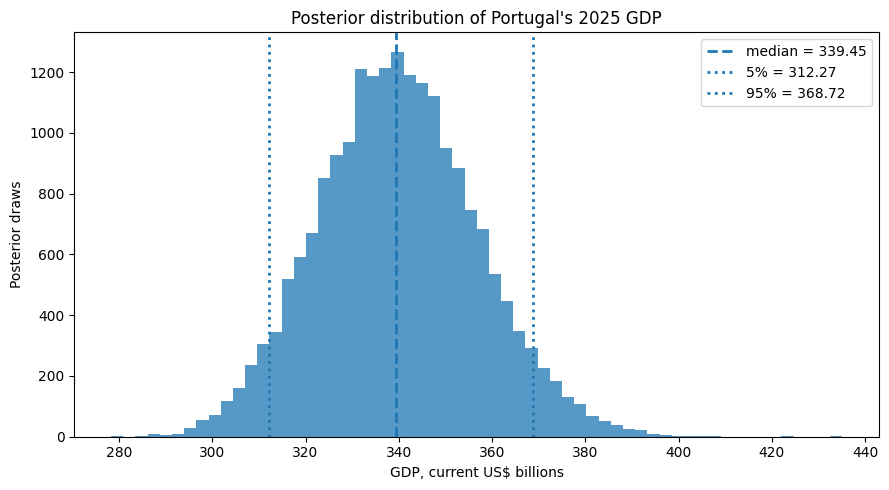

In [8]:
plot_posterior_histogram(
    gdp_result.gdp_samples / 1e9,
    title="Posterior distribution of Portugal's 2025 GDP",
    xlabel="GDP, current US$ billions",
)


## 7. Posterior GDP per capita

GDP per capita is computed from the joint posterior draws.

This preserves the dependency between population and GDP assumptions.


In [9]:
gdp_pc_samples = gdp_result.gdp_samples / population_result.samples

gdp_pc_summary = summarize_samples(gdp_pc_samples)
gdp_pc_summary


{'mean': 29777.63366624402,
 'median': 29743.500480584313,
 'sd': 1491.232347975911,
 'q5': 27362.624332725223,
 'q95': 32308.89014322124}

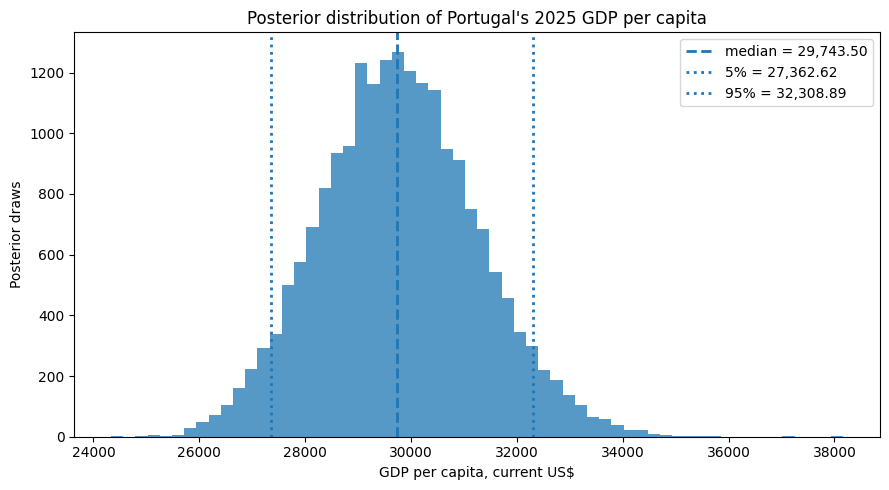

In [10]:
plot_posterior_histogram(
    gdp_pc_samples,
    title="Posterior distribution of Portugal's 2025 GDP per capita",
    xlabel="GDP per capita, current US$",
)


## 8. Labour-channel scenarios for the revised population

The weakest point in a denominator-only correction is that it assumes the extra residents raise population but do not materially raise output. That can be too pessimistic if a large share of the revision reflects migrants who are active workers.

This section makes that channel explicit. It starts from the implied increase in 2025 residents relative to the population used in the preliminary calculation, then applies three stylized labour-market scenarios:

- a **low labour-absorption** case;
- a **central migrant-worker response** case;
- a **strong migrant-worker response** case.

Each scenario translates extra residents into extra employed workers and then into extra GDP using a baseline output-per-employed benchmark from the latest observed year. These are not forecasts of truth. They are transparent conditional scenarios that show how sensitive the GDP-per-capita conclusion is to labour-market assumptions.


In [11]:
old_population_basis_2025 = revised_population_2025 / population_correction_factor
extra_residents_2025 = revised_population_2025 - old_population_basis_2025

labour_baseline = (
    panel.dropna(subset=["labor_force", "unemployment_pct", "gdp_current_usd"])
    .sort_values("year")
    .iloc[-1]
)
baseline_employed = labour_baseline["labor_force"] * (1.0 - labour_baseline["unemployment_pct"] / 100.0)
baseline_output_per_employed = labour_baseline["gdp_current_usd"] / baseline_employed

pd.Series(
    {
        "population_used_in_preliminary_ratio_basis": old_population_basis_2025,
        "revised_population_2025": revised_population_2025,
        "implied_extra_residents": extra_residents_2025,
        "baseline_year_for_output_per_worker": labour_baseline["year"],
        "baseline_employed_persons": baseline_employed,
        "baseline_output_per_employed_usd": baseline_output_per_employed,
    }
)

population_used_in_preliminary_ratio_basis    1.081821e+07
revised_population_2025                       1.142403e+07
implied_extra_residents                       6.058198e+05
baseline_year_for_output_per_worker           2.024000e+03
baseline_employed_persons                     5.095905e+06
baseline_output_per_employed_usd              6.147508e+04
dtype: float64

In [12]:
LABOUR_RESPONSE_SCENARIOS = pd.DataFrame(
    [
        {
            "scenario": "Denominator only",
            "working_age_share": 0.00,
            "participation_rate": 0.00,
            "employment_rate": 0.00,
            "productivity_relative_to_baseline_worker": 0.00,
        },
        {
            "scenario": "Low labour absorption",
            "working_age_share": 0.55,
            "participation_rate": 0.75,
            "employment_rate": 0.80,
            "productivity_relative_to_baseline_worker": 0.70,
        },
        {
            "scenario": "Central migrant-worker response",
            "working_age_share": 0.65,
            "participation_rate": 0.82,
            "employment_rate": 0.88,
            "productivity_relative_to_baseline_worker": 0.85,
        },
        {
            "scenario": "Strong migrant-worker response",
            "working_age_share": 0.75,
            "participation_rate": 0.86,
            "employment_rate": 0.92,
            "productivity_relative_to_baseline_worker": 1.00,
        },
    ]
)

base_pps_index_samples = estimate_pps_index_samples(
    preliminary_index=preliminary_pps_index,
    population_correction_factor=population_correction_factor,
    n_samples=20_000,
    random_seed=17,
)

scenario_rows = []
scenario_sample_map: dict[str, np.ndarray] = {}

for row in LABOUR_RESPONSE_SCENARIOS.itertuples(index=False):
    extra_employed = (
        extra_residents_2025
        * row.working_age_share
        * row.participation_rate
        * row.employment_rate
    )
    extra_gdp = (
        extra_employed
        * baseline_output_per_employed
        * row.productivity_relative_to_baseline_worker
    )
    scenario_gdp_samples = gdp_result.gdp_samples + extra_gdp
    scenario_gdp_pc_samples = scenario_gdp_samples / population_result.samples
    scenario_pps_factor = scenario_gdp_samples / gdp_result.gdp_samples
    scenario_pps_samples = base_pps_index_samples * scenario_pps_factor
    scenario_sample_map[row.scenario] = scenario_gdp_pc_samples

    gdp_pc_stats = summarize_samples(scenario_gdp_pc_samples)
    pps_stats = summarize_samples(scenario_pps_samples)

    scenario_rows.append(
        {
            "scenario": row.scenario,
            "extra_employed_persons": extra_employed,
            "extra_gdp_usd": extra_gdp,
            "gdp_pc_mean_usd": gdp_pc_stats["mean"],
            "gdp_pc_median_usd": gdp_pc_stats["median"],
            "gdp_pc_q5_usd": gdp_pc_stats["q5"],
            "gdp_pc_q95_usd": gdp_pc_stats["q95"],
            "pps_index_mean": pps_stats["mean"],
            "pps_index_median": pps_stats["median"],
            "pps_index_q5": pps_stats["q5"],
            "pps_index_q95": pps_stats["q95"],
        }
    )

scenario_summary = pd.DataFrame(scenario_rows)
scenario_summary

,scenario,extra_employed_persons,extra_gdp_usd,gdp_pc_mean_usd,gdp_pc_median_usd,gdp_pc_q5_usd,gdp_pc_q95_usd,pps_index_mean,pps_index_median,pps_index_q5,pps_index_q95
0,Denominator only,0.000000,0.000000e+00,29777.633666,29743.500481,27362.624333,32308.890143,76.991228,76.991112,76.340655,77.644923
1,Low labour absorption,199920.542500,8.603092e+09,30531.482287,30497.328834,28116.342732,33063.668659,78.945209,78.943017,78.261830,79.628091
2,Central migrant-worker response,284153.731073,1.484812e+10,31078.704591,31044.881831,28663.397759,33611.534579,80.363612,80.359876,79.640508,81.092556
3,Strong migrant-worker response,359493.484605,2.209989e+10,31714.143501,31680.208535,29299.593269,34246.663345,82.010674,82.004906,81.215206,82.810978


In [13]:
scenario_display = scenario_summary.copy()
for col in [
    "extra_employed_persons",
    "extra_gdp_usd",
    "gdp_pc_mean_usd",
    "gdp_pc_median_usd",
    "gdp_pc_q5_usd",
    "gdp_pc_q95_usd",
    "pps_index_mean",
    "pps_index_median",
    "pps_index_q5",
    "pps_index_q95",
]:
    scenario_display[col] = scenario_display[col].round(2)

scenario_display

,scenario,extra_employed_persons,extra_gdp_usd,gdp_pc_mean_usd,gdp_pc_median_usd,gdp_pc_q5_usd,gdp_pc_q95_usd,pps_index_mean,pps_index_median,pps_index_q5,pps_index_q95
0,Denominator only,0.00,0.000000e+00,29777.63,29743.50,27362.62,32308.89,76.99,76.99,76.34,77.64
1,Low labour absorption,199920.54,8.603092e+09,30531.48,30497.33,28116.34,33063.67,78.95,78.94,78.26,79.63
2,Central migrant-worker response,284153.73,1.484812e+10,31078.70,31044.88,28663.40,33611.53,80.36,80.36,79.64,81.09
3,Strong migrant-worker response,359493.48,2.209989e+10,31714.14,31680.21,29299.59,34246.66,82.01,82.00,81.22,82.81


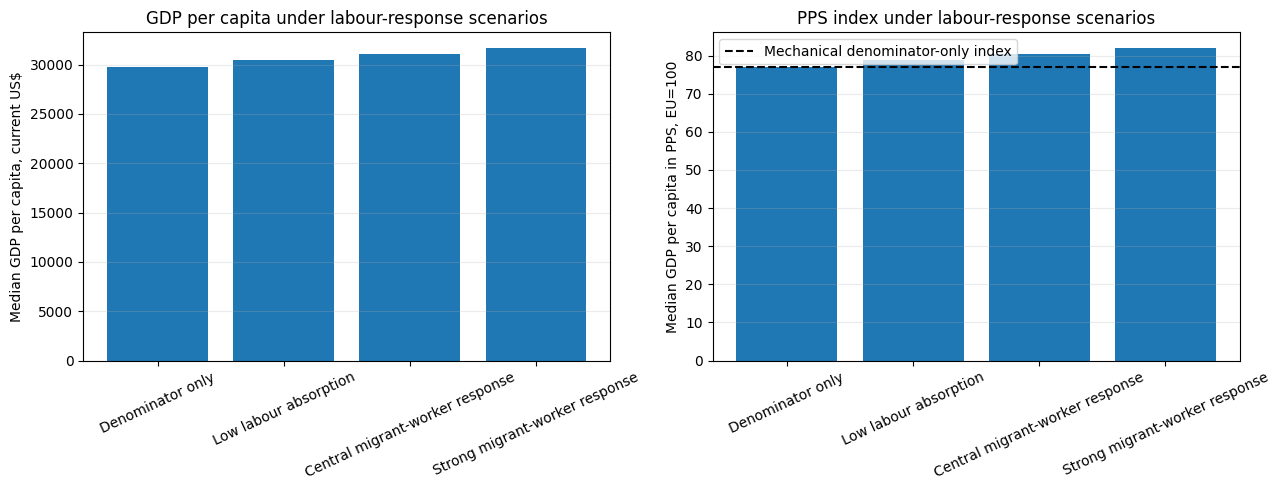

In [14]:
scenario_plot = scenario_summary.copy()
mechanical_index_baseline = preliminary_pps_index / population_correction_factor
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(scenario_plot["scenario"], scenario_plot["gdp_pc_median_usd"])
axes[0].set_title("GDP per capita under labour-response scenarios")
axes[0].set_ylabel("Median GDP per capita, current US$")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].bar(scenario_plot["scenario"], scenario_plot["pps_index_median"])
axes[1].axhline(mechanical_index_baseline, linestyle="--", linewidth=1.5, color="black", label="Mechanical denominator-only index")
axes[1].set_title("PPS index under labour-response scenarios")
axes[1].set_ylabel("Median GDP per capita in PPS, EU=100")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

The point of this scenario block is not to declare one assumption set correct. The point is to show that the sign and size of the GDP-per-capita revision depend materially on whether the population revision is treated as a labour-supply shock as well as a denominator correction.


## 9. GDP per capita in PPS: sensitivity layer

GDP per capita in PPS, EU=100, depends on more than Portugal's population. It also depends on GDP, PPPs and the EU reference average.

The simplest mechanical correction is:

```text
corrected_index = preliminary_index / population_correction_factor
```

The Bayesian sensitivity layer generalizes that by allowing GDP revisions and the EU reference average to vary.


In [15]:
pps_index_samples = estimate_pps_index_samples(
    preliminary_index=preliminary_pps_index,
    population_correction_factor=population_correction_factor,
    n_samples=20_000,
    random_seed=17,
)

pps_index_summary = summarize_samples(pps_index_samples)
mechanical_index = preliminary_pps_index / population_correction_factor

pd.Series({
    "preliminary_index": preliminary_pps_index,
    "mechanical_denominator_only_index": mechanical_index,
    **pps_index_summary,
})


preliminary_index                    81.300000
mechanical_denominator_only_index    76.988636
mean                                 76.991228
median                               76.991112
sd                                    0.394356
q5                                   76.340655
q95                                  77.644923
dtype: float64

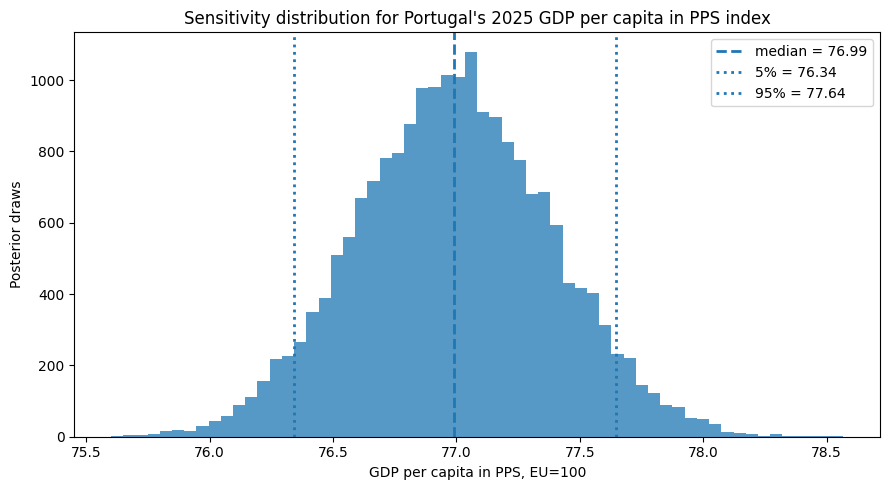

In [16]:
plot_posterior_histogram(
    pps_index_samples,
    title="Sensitivity distribution for Portugal's 2025 GDP per capita in PPS index",
    xlabel="GDP per capita in PPS, EU=100",
)


## 10. Summary table

The table below keeps the key posterior quantities together.


In [17]:
summary = pd.DataFrame(
    {
        "population_2025": summarize_samples(population_result.samples),
        "gdp_2025_current_usd": summarize_samples(gdp_result.gdp_samples),
        "gdp_pc_2025_current_usd": summarize_samples(gdp_pc_samples),
        "gdp_pc_pps_index_sensitivity": summarize_samples(pps_index_samples),
    }
).T
summary


,mean,median,sd,q5,q95
population_2025,1.141224e+07,1.141223e+07,1.125084e+04,1.139379e+07,1.143069e+07
gdp_2025_current_usd,3.398290e+11,3.394505e+11,1.701318e+10,3.122692e+11,3.687174e+11
gdp_pc_2025_current_usd,2.977763e+04,2.974350e+04,1.491232e+03,2.736262e+04,3.230889e+04
gdp_pc_pps_index_sensitivity,7.699123e+01,7.699111e+01,3.943555e-01,7.634065e+01,7.764492e+01


## 11. Interpretation

The relevant output is not a single number. It is a distribution.

A denominator-only correction is useful as a first approximation. But a Bayesian approach makes the uncertainty explicit and lets GDP be updated instead of treating it as fixed.

The claim we can make after this model is more precise:

> Given the revised population estimate, Portugal's 2025 GDP per capita cannot be interpreted from the denominator effect alone. The direction and size of the revision depend on how much of the extra population translates into labour supply, employment, output, GDP revisions, PPPs and the EU reference average.

That is stronger than rhetoric and easier to audit.
